# 04 — Unicorn hunting

Goal: find players whose **combination** of traits is statistically rare relative to their peers, not simply the best players.

## Step 4A — Position spectrum (decision D5)

Three estimates of position, all on the same **1 (G) → 5 (C)** scale:

| Column | Source |
|---|---|
| `position_num` | **listed** on that season's roster (G=1, G-F=2, F-G=2.5, F=3, F-C=3.5, C-F=4, C=5) |
| `position_body` | predicted from **height and weight** only |
| `position_style` | predicted from **how he plays** only: passing, rebounding, rim protection, steals, shot locations, free throws, usage, self-creation, transition (season-relative z-scores, no body measures) |

The gaps are unicorn signals. `style_vs_body < 0` means a big body that plays small (Jokić, Giannis); `style_vs_listed` shows a player who plays bigger or smaller than his listing.

Models are ridge regressions fitted on rotation players (≥ 500 min) from **that season and earlier only**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from unicorn.plotting import apply_style, BLUE, ORANGE, INK, INK2, MUTED, FIG_DIR
from unicorn.position import add_position_spectrum, style_coefficients
from unicorn.raw import PROJECT_ROOT

apply_style()
traj = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_trajectories.parquet")
uni = add_position_spectrum(traj)
print(uni.shape)

(7889, 553)


### How well does style predict listed position, on seasons the model has not seen?

The model is fitted on seasons before *t*, and accuracy is measured on season *t*.

,n,MAE_style,R2_style,R2_body
season_start,,,,
2012,341.0,0.533,0.767,0.801
2013,334.0,0.516,0.769,0.830
2014,362.0,0.513,0.773,0.828
2015,346.0,0.484,0.790,0.831
2016,349.0,0.550,0.748,0.805
2017,350.0,0.522,0.766,0.799
2018,354.0,0.525,0.764,0.804
2019,337.0,0.517,0.732,0.790
2020,361.0,0.555,0.710,0.797


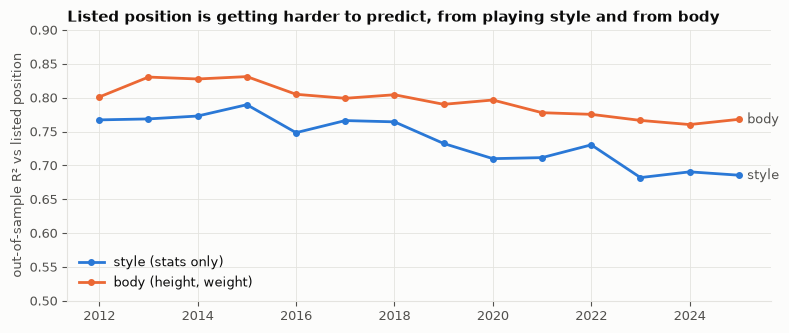

In [2]:
held = add_position_spectrum(traj, holdout=True)
ev = held[(held["position_source"] == "roster") & (held["min"] >= 500) & held["position_style"].notna()]
acc = ev.groupby("season_start").apply(lambda g: pd.Series({
    "n": len(g), "MAE_style": mean_absolute_error(g["position_num"], g["position_style"]),
    "R2_style": r2_score(g["position_num"], g["position_style"]),
    "R2_body": r2_score(g["position_num"], g["position_body"])}), include_groups=False)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(acc.index, acc["R2_style"], color=BLUE, marker="o", markersize=4, label="style (stats only)")
ax.plot(acc.index, acc["R2_body"], color=ORANGE, marker="o", markersize=4, label="body (height, weight)")
for col, color in [("R2_style", BLUE), ("R2_body", ORANGE)]:
    ax.annotate(col.split("_")[1], (acc.index[-1], acc[col].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK2)
ax.set_ylabel("out-of-sample R² vs listed position"); ax.set_ylim(0.5, 0.9)
ax.legend(frameon=False, loc="lower left")
ax.set_title("Listed position is getting harder to predict, from playing style and from body", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_position_predictability.png", dpi=150, bbox_inches="tight")
acc.round(3)

### What the style model looks at

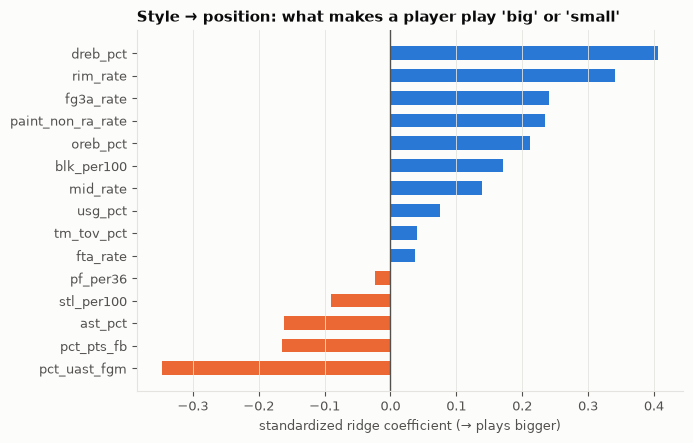

In [3]:
coef = style_coefficients(uni)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(coef.index.str.replace("_z", ""), coef.values, color=np.where(coef > 0, BLUE, ORANGE), height=0.6)
ax.axvline(0, color=INK2, linewidth=1)
ax.set_xlabel("standardized ridge coefficient (→ plays bigger)")
ax.set_title("Style → position: what makes a player play 'big' or 'small'", loc="left")
ax.grid(axis="y", visible=False)
fig.tight_layout(); fig.savefig(FIG_DIR / "04_style_coefficients.png", dpi=150, bbox_inches="tight")

Read the coefficients jointly. The shot-location shares partly sum to one, so e.g. `fg3a_rate` is positive *given* rim and mid-range rates. The clear signals: rebounding and rim shots → big; self-creation, assists and transition scoring → small.

### Body vs style, 2025-26

Each dot is a rotation player. On the diagonal, he plays the position his body suggests. **Below the diagonal, he plays smaller than his body**, which is where big-bodied creators live.

not in 2025-26 rotation sample: []


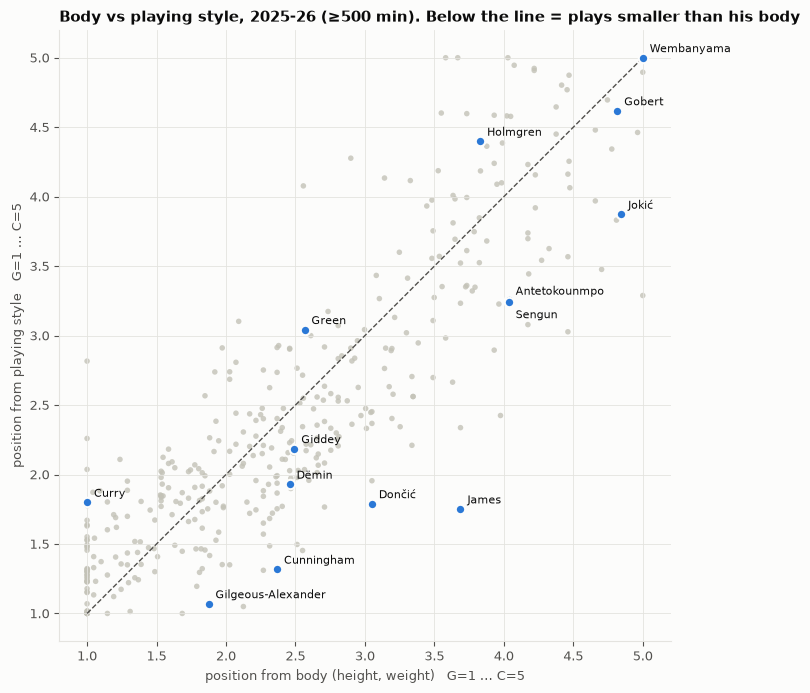

In [4]:
s = uni[(uni["season"] == "2025-26") & (uni["min"] >= 500)]
highlight = ["Nikola Jokić", "Giannis Antetokounmpo", "Victor Wembanyama", "LeBron James", "Luka Dončić",
             "Stephen Curry", "Josh Giddey", "Egor Dëmin", "Rudy Gobert", "Shai Gilgeous-Alexander", "Cade Cunningham",
             "Chet Holmgren", "Alperen Sengun", "Draymond Green"]
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([1, 5], [1, 5], color=INK2, linewidth=1, linestyle="--")
ax.scatter(s["position_body"], s["position_style"], s=16, color=MUTED, edgecolor="none", alpha=0.8)
h = s[s["player_name"].isin(highlight)]
ax.scatter(h["position_body"], h["position_style"], s=46, color=BLUE, edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
label_offsets = {"Alperen Sengun": (5, -12)}  # avoid overlapping Antetokounmpo
for _, r in h.iterrows():
    ax.annotate(r["player_name"].split()[-1], (r["position_body"], r["position_style"]),
                xytext=label_offsets.get(r["player_name"], (5, 4)),
                textcoords="offset points", fontsize=8, color=INK)
ax.set_xlabel("position from body (height, weight)   G=1 … C=5"); ax.set_ylabel("position from playing style   G=1 … C=5")
ax.set_xlim(0.8, 5.2); ax.set_ylim(0.8, 5.2); ax.set_aspect("equal")
ax.set_title("Body vs playing style, 2025-26 (≥500 min). Below the line = plays smaller than his body", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_body_vs_style_2025_26.png", dpi=150, bbox_inches="tight")
missing = sorted(set(highlight) - set(h["player_name"]))
print("not in 2025-26 rotation sample:", missing)

In [5]:
cols = ["player_name", "season", "height_in", "position_listed", "position_num", "position_body", "position_style", "style_vs_body"]
rot = uni[uni["min"] >= 1000]
print("Plays smallest relative to his body (all seasons, ≥1000 min):")
display(rot.nsmallest(12, "style_vs_body")[cols].round(2))
print("Plays biggest relative to his body:")
display(rot.nlargest(8, "style_vs_body")[cols].round(2))

Plays smallest relative to his body (all seasons, ≥1000 min):


,player_name,season,height_in,position_listed,position_num,position_body,position_style,style_vs_body
356,LeBron James,2019-20,81.0,F,3.0,3.74,1.37,-2.37
357,LeBron James,2020-21,81.0,F,3.0,3.74,1.73,-2.02
4593,Ben Simmons,2020-21,83.0,G-F,2.0,4.01,2.02,-1.99
362,LeBron James,2025-26,81.0,F,3.0,3.69,1.75,-1.94
360,LeBron James,2023-24,81.0,F,3.0,3.73,1.82,-1.91
4167,Joe Ingles,2022-23,81.0,F-G,2.5,3.13,1.24,-1.89
351,LeBron James,2014-15,80.0,F,3.0,3.27,1.41,-1.85
359,LeBron James,2022-23,81.0,F,3.0,3.75,2.03,-1.72
1422,Brook Lopez,2025-26,85.0,C,5.0,5.00,3.29,-1.71
355,LeBron James,2018-19,80.0,F,3.0,3.41,1.70,-1.71


Plays biggest relative to his body:


,player_name,season,height_in,position_listed,position_num,position_body,position_style,style_vs_body
4825,Gary Payton II,2025-26,74.0,G,1.0,1.00,2.82,1.82
345,Reggie Evans,2012-13,80.0,F,3.0,3.22,5.00,1.78
2146,Ed Davis,2018-19,82.0,C,5.0,3.32,5.00,1.68
2431,Bismack Biyombo,2013-14,81.0,C-F,4.0,3.38,5.00,1.62
2433,Bismack Biyombo,2015-16,81.0,C-F,4.0,3.40,5.00,1.60
2432,Bismack Biyombo,2014-15,81.0,C-F,4.0,3.38,4.97,1.59
2590,Kenneth Faried,2011-12,80.0,F,3.0,2.84,4.42,1.58
7391,Moussa Diabaté,2024-25,81.0,F,3.0,2.90,4.47,1.57


In [6]:
print("Egor Dëmin:")
uni.loc[uni["player_id"] == 1642856, cols + ["min"]].round(2)

Egor Dëmin:


,player_name,season,height_in,position_listed,position_num,position_body,position_style,style_vs_body,min
7829,Egor Dëmin,2025-26,80.0,G,1.0,2.46,1.93,-0.53,1308.21


### Step 4A findings

- **Style predicts listed position well**: out-of-sample R² 0.68–0.79, typically about half a position off. Body predicts slightly better (0.76–0.83).
- **The league is becoming positionless.** Both fall over time: style R² from about 0.77 (2012-18) to about 0.69 (2023-26), body from about 0.83 to about 0.77. Listed positions are converging less with both body and role.
- **What "plays big"**: defensive rebounding, rim attempts, offensive rebounding, blocks. **What "plays small"**: self-creation (unassisted FG share, the strongest), assists, transition scoring, steals.
- **Biggest body-vs-style gaps (≥ 1000 min, all seasons):**
  - **Bodies playing smaller:** LeBron James (repeatedly, down to −2.4 positions), Ben Simmons, Joe Ingles, Brook Lopez 2025-26 (a 7-1 center who now plays like a forward), Andrea Bargnani.
  - **Bodies playing bigger:** Gary Payton II, Reggie Evans, Biyombo, Faried (undersized rebounders and rim runners).
- **2025-26:** Luka, Cade, SGA and LeBron sit well below the line (big ball-handlers); Jokić and Giannis/Sengün are bigs who play like forwards; Holmgren plays bigger than his frame; Wembanyama is a true 5 in both body and style.
- **Egor Dëmin** (rookie, 1,308 min): listed G, 6-8, **body ≈ 2.5 (wing), style ≈ 1.9 (guard)**, so he plays about half a position smaller than his body. That's a mild version of the big-ball-handler profile, not yet an extreme one.

## Step 4B — Unicorn scores (decision D16)

Two complementary scores, each comparing a player **only with that season's players** (no leakage):

**(b) `unicorn_score`: a rare combination of strengths.** 15 traits (size, both rebounding types, rim protection, steals, finishing, passing, self-creation, 3-point volume and accuracy, FT touch, usage, efficiency, FT drawing, ball security).
- For every pair of traits, measure how often rotation players are **strong (top 20%) in both**. By chance that would be 4%.
- A player earns the *excess* rarity of each pair he's strong in. Common pairs (size + rebounding) add nothing, and being #1 at one skill doesn't count. Many rare pairs = a high score.

**(a) `strangeness`: unusual in any direction.** Mean distance to his **5 most similar rotation players** that season. A traditional center has many near-twins; Wembanyama has none. This also flags strange-but-not-elite players.

A first attempt for each score was rejected after testing (documented in findings): the "rarest single pair" saturated, and a Mahalanobis distance flagged the whole cluster of 2012 traditional centers.

In [7]:
from unicorn.unicorn import TRAITS, add_strangeness, add_unicorn_score, pair_rarity
from unicorn.plotting import DIVERGING, SURFACE

uni = add_strangeness(add_unicorn_score(uni))
QUALITY = uni["pie_pctl"] >= 0.5          # at least median overall impact vs that season's rotation players
SAMPLE = uni["min"] >= 1000
print(uni[["unicorn_score", "strangeness"]].describe().round(2))

       unicorn_score  strangeness
count        7889.00      7889.00
mean            0.26         2.73
std             0.58         1.03
min             0.00         1.30
25%             0.00         2.09
50%             0.00         2.44
75%             0.25         2.99
max             6.09        10.64


### Which strength combinations are rare? (averaged over 2011-26; 1.0 = as common as chance)

Rarest pairs:


trait_a          trait_b      
off. rebounding  3pt volume       0.02
rim protection   self-creation    0.10
3pt volume       FT drawing       0.10
off. rebounding  3pt accuracy     0.11
                 self-creation    0.12
                 FT touch         0.16
def. rebounding  3pt volume       0.18
off. rebounding  passing          0.18
self-creation    3pt volume       0.19
rim protection   FT touch         0.21
Name: share_both, dtype: float64

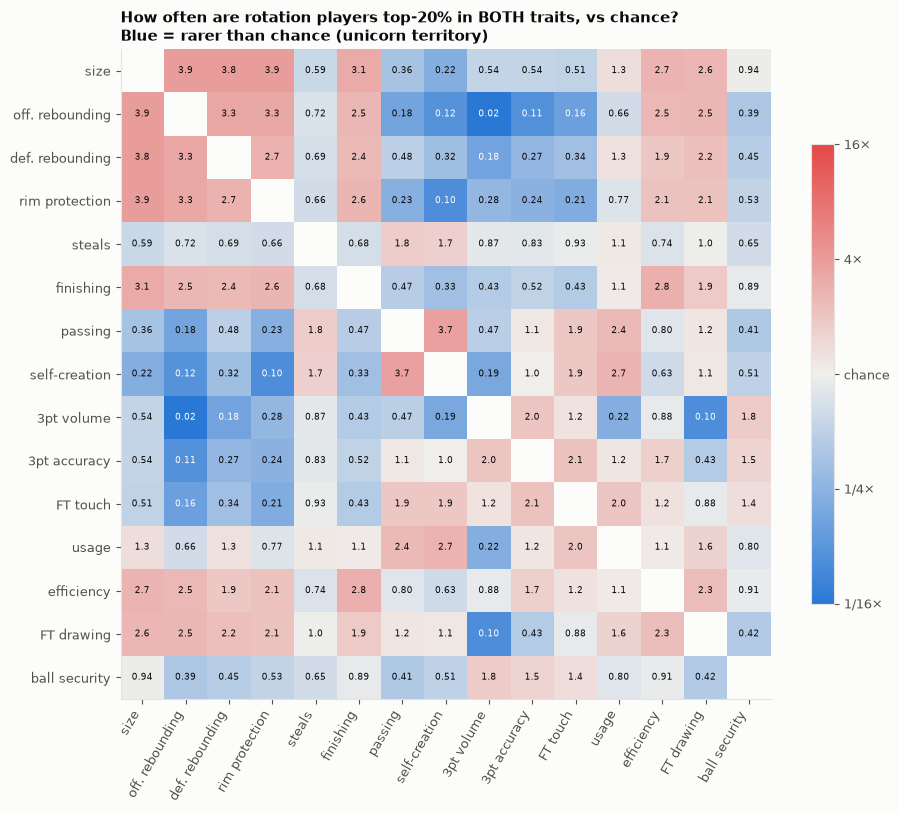

In [8]:
rar = pair_rarity(uni)
lift = rar.groupby(["trait_a", "trait_b"])["share_both"].mean() / 0.04
labels = list(TRAITS)
M = pd.DataFrame(np.nan, index=labels, columns=labels)
for (a, b), v in lift.items():
    M.loc[a, b] = M.loc[b, a] = v
fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(np.log2(M.clip(lower=1 / 16)), cmap=DIVERGING, vmin=-4, vmax=4)
ax.set_xticks(range(len(labels)), labels, rotation=60, ha="right"); ax.set_yticks(range(len(labels)), labels)
ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            v = M.iloc[i, j]
            ax.text(j, i, f"{v:.1f}" if v >= 0.95 else f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color=SURFACE if abs(np.log2(max(v, 1 / 16))) > 2.5 else INK)
cb = fig.colorbar(im, ax=ax, shrink=0.7, ticks=[-4, -2, 0, 2, 4])
cb.ax.set_yticklabels(["1/16×", "1/4×", "chance", "4×", "16×"])
ax.set_title("How often are rotation players top-20% in BOTH traits, vs chance?\nBlue = rarer than chance (unicorn territory)", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_trait_pair_rarity.png", dpi=150, bbox_inches="tight")
print("Rarest pairs:"); (lift.sort_values().head(10)).round(2)

### Top unicorn seasons (≥ 1,000 min, at least median overall impact)

In [9]:
cols = ["player_name", "season", "age", "min", "unicorn_score", "unicorn_pairs"]
display(uni[SAMPLE & QUALITY].nlargest(20, "unicorn_score")[cols].round(2))

career = (uni[SAMPLE & QUALITY].groupby("player_name")
          .agg(seasons=("season", "size"), mean_unicorn=("unicorn_score", "mean"), best=("unicorn_score", "max"),
               mean_strangeness_pctl=("strangeness_pctl", "mean")))
print("Career unicorns (≥ 3 qualifying seasons):")
career[career["seasons"] >= 3].nlargest(15, "mean_unicorn").round(2)

,player_name,season,age,min,unicorn_score,unicorn_pairs
3583,Giannis Antetokounmpo,2019-20,25.16,1916.88,5.31,"rim protection + passing, rim protection + sel..."
4114,Kristaps Porziņģis,2021-22,26.50,1480.62,5.21,"FT drawing + ball security, off. rebounding + ..."
842,Andray Blatche,2012-13,26.45,1555.18,4.88,"size + self-creation, off. rebounding + self-c..."
3585,Giannis Antetokounmpo,2021-22,27.16,2204.22,4.82,"rim protection + self-creation, size + self-cr..."
4275,Karl-Anthony Towns,2018-19,23.21,2544.66,4.74,"off. rebounding + FT touch, off. rebounding + ..."
4010,Joel Embiid,2020-21,26.88,1585.10,4.64,"off. rebounding + self-creation, rim protectio..."
3582,Giannis Antetokounmpo,2018-19,24.16,2358.22,4.56,"rim protection + self-creation, size + self-cr..."
2659,Jimmy Butler III,2022-23,33.38,2138.02,4.56,"off. rebounding + FT touch, off. rebounding + ..."
1076,Kevin Durant,2020-21,32.34,1156.77,4.51,"rim protection + 3pt accuracy, rim protection ..."
1356,Kevin Love,2011-12,23.40,2145.47,4.50,"FT drawing + ball security, off. rebounding + ..."


Career unicorns (≥ 3 qualifying seasons):


,seasons,mean_unicorn,best,mean_strangeness_pctl
player_name,,,,
Giannis Antetokounmpo,12,3.12,5.31,0.93
Nikola Jokić,11,2.42,4.08,0.94
Kevin Durant,13,2.34,4.51,0.92
Joel Embiid,8,2.11,4.64,0.95
Karl-Anthony Towns,10,2.11,4.74,0.88
LeBron James,15,1.95,4.32,0.90
LaMarcus Aldridge,10,1.72,3.84,0.72
Ryan Anderson,3,1.65,3.18,0.80
Kristaps Porziņģis,9,1.65,5.21,0.85


### Strangest seasons (≥ 1,000 min, any quality)

In [10]:
display(uni[SAMPLE].nlargest(15, "strangeness")[["player_name", "season", "strangeness", "strangeness_pctl", "strange_traits", "pie_pctl"]].round(2))

,player_name,season,strangeness,strangeness_pctl,strange_traits,pie_pctl
345,Reggie Evans,2012-13,5.80,1.00,"def. rebounding, FT drawing, ball security",0.68
1706,Stephen Curry,2015-16,5.28,1.00,"3pt accuracy, efficiency, finishing",1.00
7487,Victor Wembanyama,2023-24,4.99,1.00,"rim protection, ball security, usage",0.98
192,Pau Gasol,2016-17,4.85,1.00,"3pt accuracy, FT touch, def. rebounding",0.92
2893,Andre Drummond,2019-20,4.83,1.00,"def. rebounding, steals, ball security",0.95
178,Tyson Chandler,2011-12,4.79,1.00,"FT drawing, efficiency, usage",0.91
7014,Jericho Sims,2025-26,4.78,1.00,"ball security, efficiency, rim protection",0.37
519,Dwight Howard,2011-12,4.75,0.99,"FT drawing, def. rebounding, FT touch",0.99
7489,Victor Wembanyama,2025-26,4.74,1.00,"rim protection, def. rebounding, size",0.99
528,Dwight Howard,2020-21,4.54,1.00,"ball security, def. rebounding, FT drawing",0.87


### Sanity check against well-known unicorns

Not used for tuning, only to check the scores say something sensible. Percentiles are among all player-seasons with ≥ 1,000 min.

In [11]:
known = ["Victor Wembanyama", "Nikola Jokić", "Giannis Antetokounmpo", "Joel Embiid", "LeBron James", "Ben Simmons",
         "Kristaps Porziņģis", "Draymond Green", "Stephen Curry", "Kevin Durant", "Karl-Anthony Towns", "Chet Holmgren",
         "Rudy Gobert", "Josh Giddey", "Egor Dëmin"]
s = uni[SAMPLE].copy()
s["unicorn_pctl_all"] = s["unicorn_score"].rank(pct=True)
s["strangeness_pctl_all"] = s["strangeness"].rank(pct=True)
(s[s["player_name"].isin(known)].groupby("player_name")
 .agg(seasons=("season", "size"), unicorn_pctl=("unicorn_pctl_all", "mean"), strangeness_pctl=("strangeness_pctl_all", "mean"))
 .sort_values("unicorn_pctl", ascending=False).round(2))

,seasons,unicorn_pctl,strangeness_pctl
player_name,,,
Kevin Durant,13,0.98,0.93
Nikola Jokić,11,0.97,0.94
LeBron James,15,0.96,0.90
Kristaps Porziņģis,9,0.92,0.85
Ben Simmons,6,0.91,0.98
Stephen Curry,13,0.91,0.73
Joel Embiid,8,0.89,0.95
Karl-Anthony Towns,10,0.88,0.88
Giannis Antetokounmpo,13,0.83,0.91


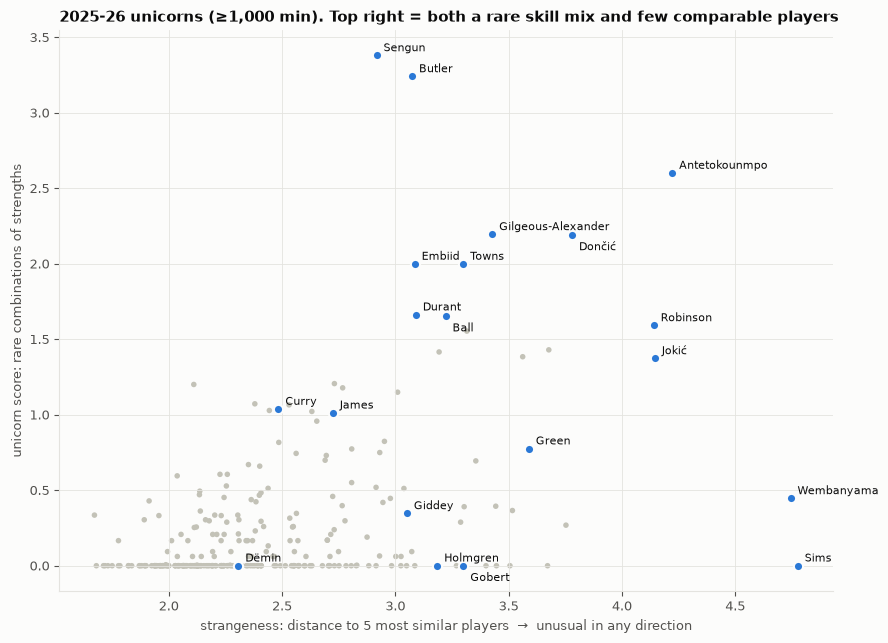

In [12]:
s = uni[(uni["season"] == "2025-26") & (uni["min"] >= 1000)]
hl = s[s["player_name"].isin(known) | (s["unicorn_score"] >= s["unicorn_score"].quantile(0.97)) | (s["strangeness_pctl"] >= 0.98)]
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(s["strangeness"], s["unicorn_score"], s=16, color=MUTED, edgecolor="none")
ax.scatter(hl["strangeness"], hl["unicorn_score"], s=44, color=BLUE, edgecolor=SURFACE, linewidth=1.5, zorder=3)
def short_name(name):
    parts = [p for p in name.split() if p not in {"Jr.", "Sr.", "II", "III", "IV"}]
    return parts[-1]

offsets = {"Luka Dončić": (5, -11), "LaMelo Ball": (5, -11), "Rudy Gobert": (5, -11)}
for _, r in hl.iterrows():
    ax.annotate(short_name(r["player_name"]), (r["strangeness"], r["unicorn_score"]),
                xytext=offsets.get(r["player_name"], (5, 3)),
                textcoords="offset points", fontsize=8, color=INK)
ax.set_xlabel("strangeness: distance to 5 most similar players  →  unusual in any direction")
ax.set_ylabel("unicorn score: rare combinations of strengths")
ax.set_title("2025-26 unicorns (≥1,000 min). Top right = both a rare skill mix and few comparable players", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_unicorn_map_2025_26.png", dpi=150, bbox_inches="tight")

### Robustness: does the "strong = top 20%" cut-off matter?

In [13]:
base_top = set(career[career["seasons"] >= 3].nlargest(15, "mean_unicorn").index)
for thr in [0.75, 0.85]:
    alt = add_unicorn_score(traj.assign(), strong=thr)
    alt = alt[(alt["min"] >= 1000) & (alt["pie_pctl"] >= 0.5)].groupby("player_name").agg(n=("season", "size"), m=("unicorn_score", "mean"))
    top = set(alt[alt["n"] >= 3].nlargest(15, "m").index)
    print(f"strong = top {1 - thr:.0%}: {len(base_top & top)}/15 of the career top-15 unchanged")

strong = top 25%: 12/15 of the career top-15 unchanged


strong = top 15%: 12/15 of the career top-15 unchanged


In [14]:
print("Egor Dëmin:")
display(uni.loc[uni["player_id"] == 1642856, ["season", "min", "unicorn_score", "unicorn_pairs", "strangeness", "strangeness_pctl", "strange_traits"]].round(2))
strengths = pd.Series({t: uni.loc[uni["player_id"] == 1642856, f"{c}_pctl"].iloc[0] for t, c in TRAITS.items()})
strengths["ball security"] = 1 - strengths["ball security"]
print("Trait percentiles vs 2025-26 rotation players:"); strengths.sort_values(ascending=False).round(2)

Egor Dëmin:


,season,min,unicorn_score,unicorn_pairs,strangeness,strangeness_pctl,strange_traits
7829,2025-26,1308.21,0.0,,2.31,0.46,"size, FT touch, 3pt volume"


Trait percentiles vs 2025-26 rotation players:


3pt volume         0.94
3pt accuracy       0.86
passing            0.74
FT touch           0.74
size               0.73
usage              0.53
def. rebounding    0.47
steals             0.46
rim protection     0.44
self-creation      0.39
efficiency         0.33
FT drawing         0.19
ball security      0.18
off. rebounding    0.10
finishing          0.08
dtype: float64

In [15]:
uni.to_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_unicorn.parquet", index=False)
print("saved player_season_unicorn.parquet", uni.shape)

saved player_season_unicorn.parquet (7889, 558)


### Step 4B findings

**The rarest strength combinations** (how often rotation players are top-20% in both, vs chance): offensive rebounding + 3-point volume (**0.02×**, essentially nobody), rim protection + self-creation (0.10×), 3-point volume + drawing fouls (0.10×), offensive rebounding + 3-point accuracy (0.11×), offensive rebounding + self-creation (0.12×). The most common are size with rebounding or rim protection (3–4× chance) and passing + self-creation (3.7×).

**Career unicorns** (combination score, ≥ 3 qualifying seasons): Giannis, Jokić, Durant, Embiid, Towns, LeBron, Aldridge, Porziņģis, Dirk, Love, Curry, Anthony Davis, Luka. Every name on the list is defensible.

**Two scores, two kinds of unicorn:**
- *Combination unicorns* (rare skill mixes): Durant, Jokić, LeBron, Porziņģis at the 92nd–98th percentile.
- *Extreme unicorns* (no comparable players): **Wembanyama is the strangest player in the dataset** (100th percentile). His combination score is only moderate (83rd), because his uniqueness is extremeness in size, rim protection and volume rather than a mix of traits that rarely go together.
- Gobert scores **0** on combinations (his strengths, size + rebounding + rim protection, are a *common* bundle) but 90th on strangeness (he is an extreme version of it). That is the intended behaviour.

**2025-26:** Sengün and Jimmy Butler have the rarest skill mixes; Giannis, Dončić and Shai are high on both; Wembanyama and Jericho Sims are the most extreme.

**Robustness:** changing "strong" from top 20% to top 15% or top 25% leaves 12 of the 15 career unicorns unchanged.

**Caveats:**
- Some traits describe *style* rather than *quality* (self-creation, 3-point volume, usage), so a few low-efficiency role players score (Andray Blatche 2012-13). The headline lists filter on at least median overall impact, and the unfiltered score is kept.
- Strangeness also flags extreme-but-limited players (Reggie Evans, Drummond). By design it means "unusual", not "good".

**Egor Dëmin (rookie):** unicorn score 0, strangeness at the 46th percentile, so a statistically ordinary profile this season. His strengths are 3-point volume (94th percentile) and accuracy (86th), with passing, FT touch and size around the 74th. His weaknesses are finishing (8th), offensive rebounding (10th) and ball security (18th). The interesting part is the *shape*: a 6-8 guard who is a high-volume shooter and secondary passer. Whether that shape predicts growth is a question for the breakout notebooks.